<a href="https://colab.research.google.com/github/KunjalGarg27/Smartphone-Addiction-Prediction-Using-Machine-Learning/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: DATASET LOADED

Dataset Shape: (7500, 16)
Total Records : 7500
Total Columns : 16

First 5 Rows:
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0 

<Figure size 1400x500 with 0 Axes>

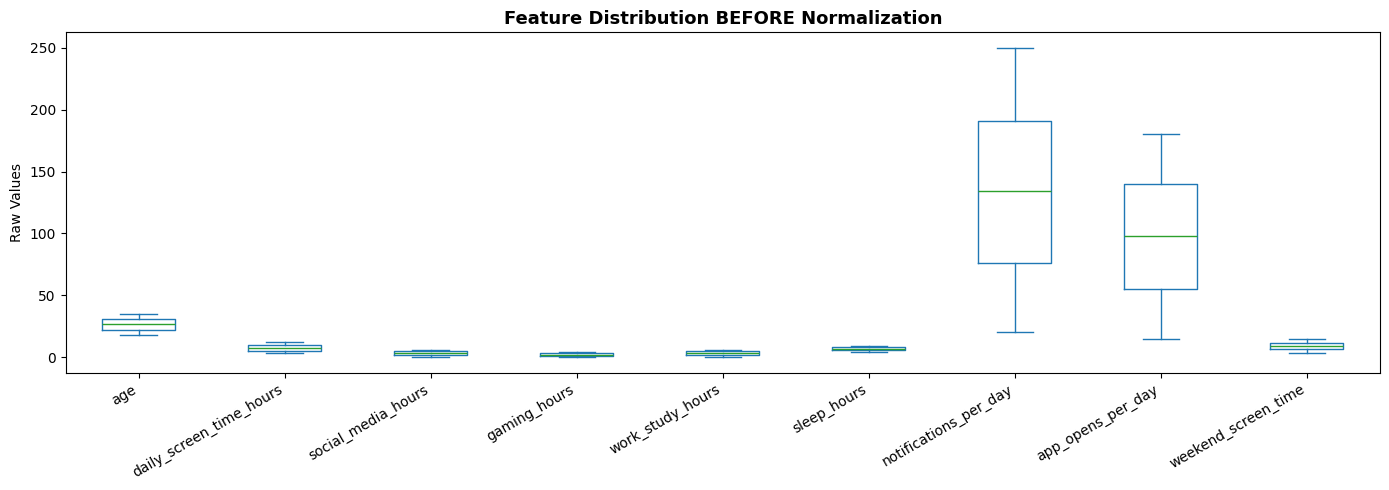


Saved: 01_before_normalization.png

Label Encoding Applied:
  gender              → Female=0, Male=1, Other=2
  stress_level        → High=0, Low=1, Medium=2
  academic_work_impact→ No=0, Yes=1

Min-Max Normalization — Sample Values:
Feature                        Raw        Min      Max      Normalized
-----------------------------------------------------------------
  daily_screen_time_hours      3.23       3.0      12.0     0.0256
  daily_screen_time_hours      7.83       3.0      12.0     0.5367
  social_media_hours           2.01       0.5      6.0      0.2745
  sleep_hours                  7.55       4.5      9.0      0.6778
  notifications_per_day        248        20       250      0.9913
  age                          21         18       35       0.1765


<Figure size 1400x500 with 0 Axes>

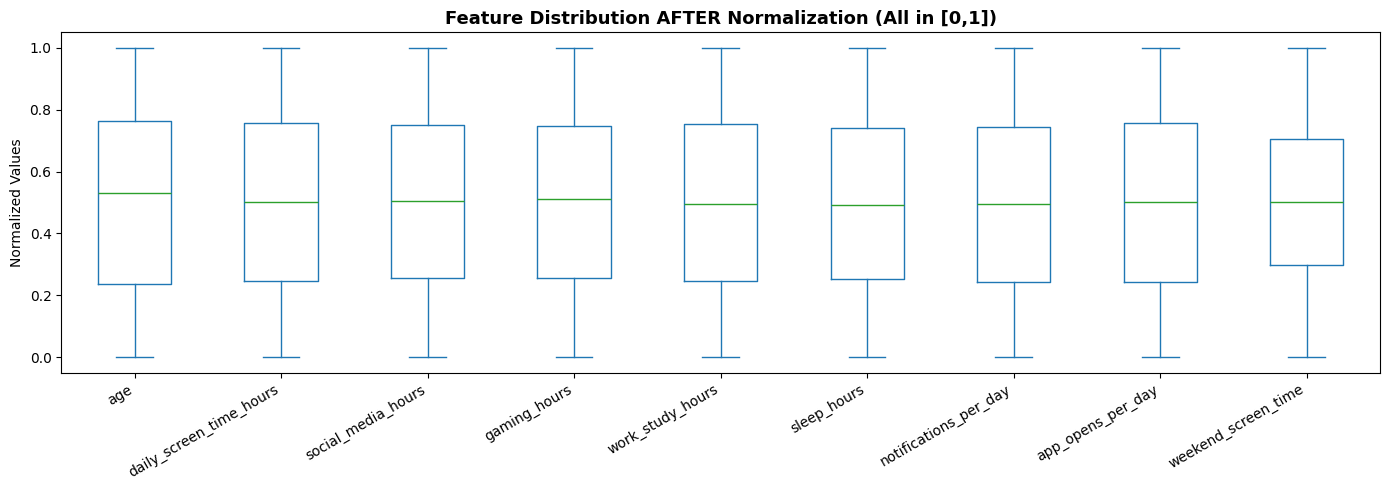


Saved: 02_after_normalization.png


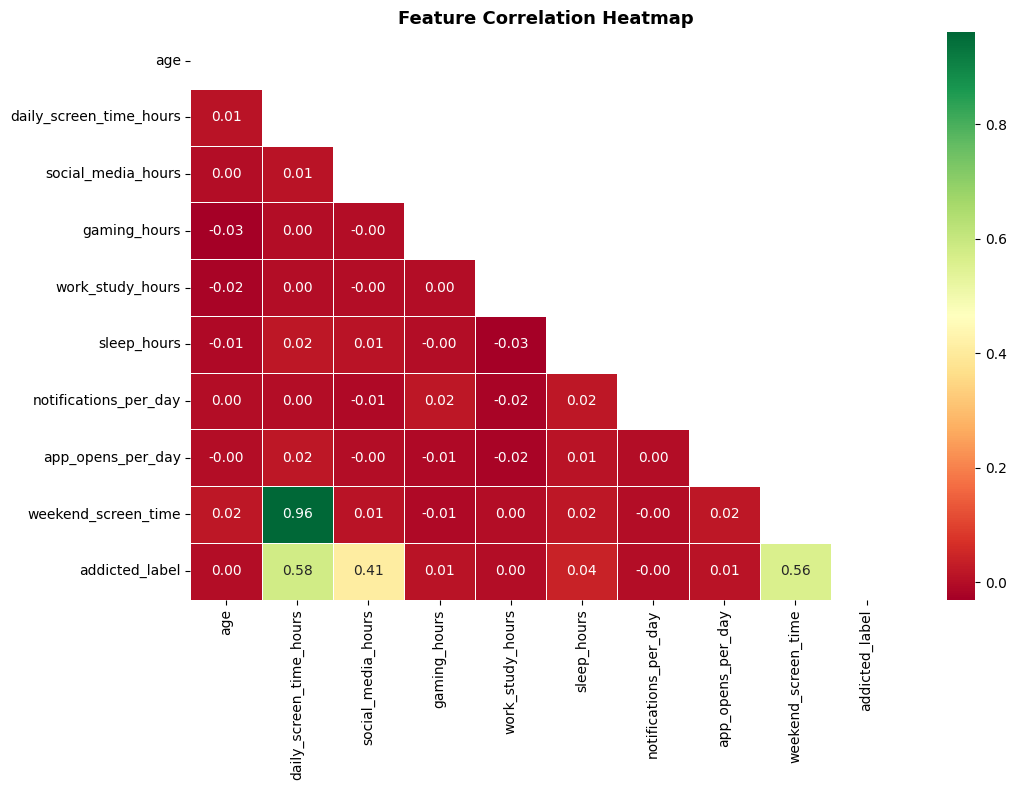

Saved: 03_correlation_heatmap.png

Class Distribution (Target: addicted_label):
addicted_label
1    5308
0    2192
Name: count, dtype: int64

  Not Addicted (0): 2192 (29.2%)
  Addicted     (1): 5308 (70.8%)


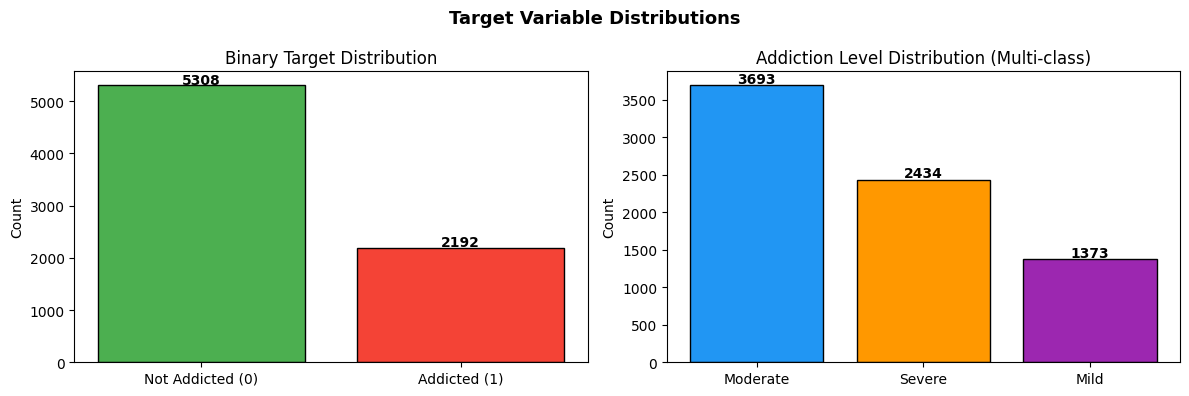

Saved: 04_class_distribution.png

✔ Train size: 6000 rows (80%)
✔ Test  size: 1500 rows  (20%)

STEP 3: DECISION TREE — GINI IMPURITY

Hyperparameter Trials (Gini):
Depth      Train Acc      Test Acc       F1 Score     Observation
----------------------------------------------------------------------
  3        0.9377         0.9407         0.9563       Good – small gap
  5        0.9422         0.9307         0.9519       Good – small gap
  10       0.9647         0.9293         0.9502       Slight overfit
  None     1.0000         0.9333         0.9531       Overfitting

--- Best Gini Model Results (depth=3) ---
Accuracy  : 0.9407
Precision : 0.9990  ← Out of all predicted 'Addicted', how many were correct?
Recall    : 0.9171  ← Out of all actual 'Addicted', how many did we catch?
F1 Score  : 0.9563  ← Harmonic mean of Precision and Recall
Tree Depth: 3   Num Leaves: 6

Classification Report (Gini):
              precision    recall  f1-score   support

Not Addicted       0.83      1

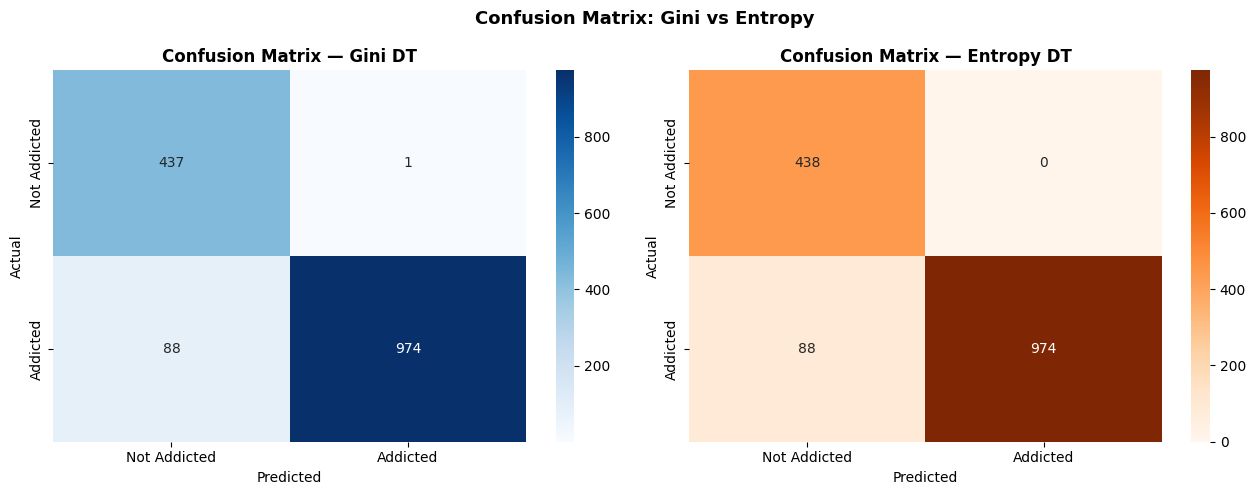

Saved: 05_confusion_matrices.png


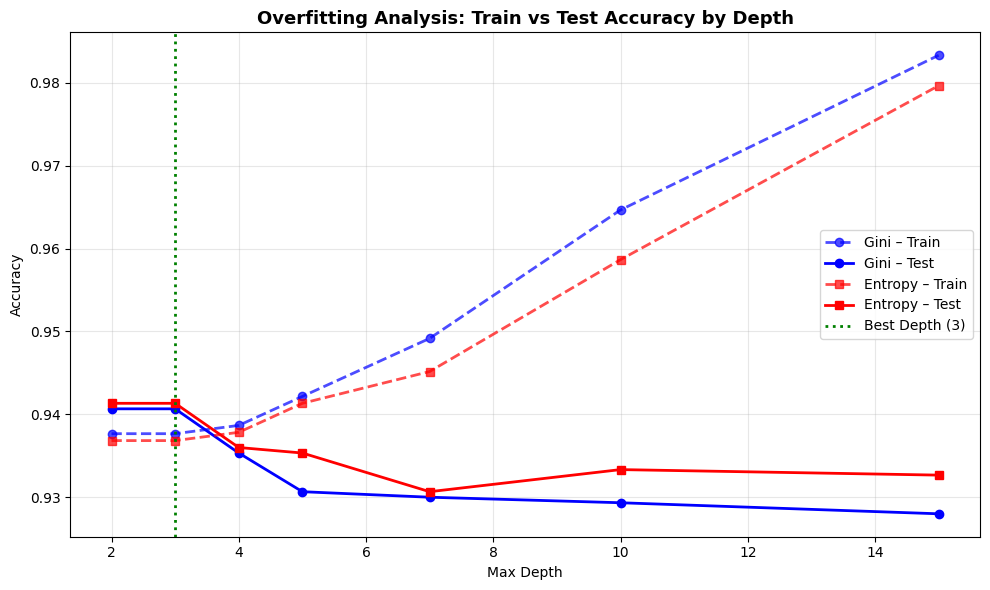

Saved: 06_overfitting_curve.png


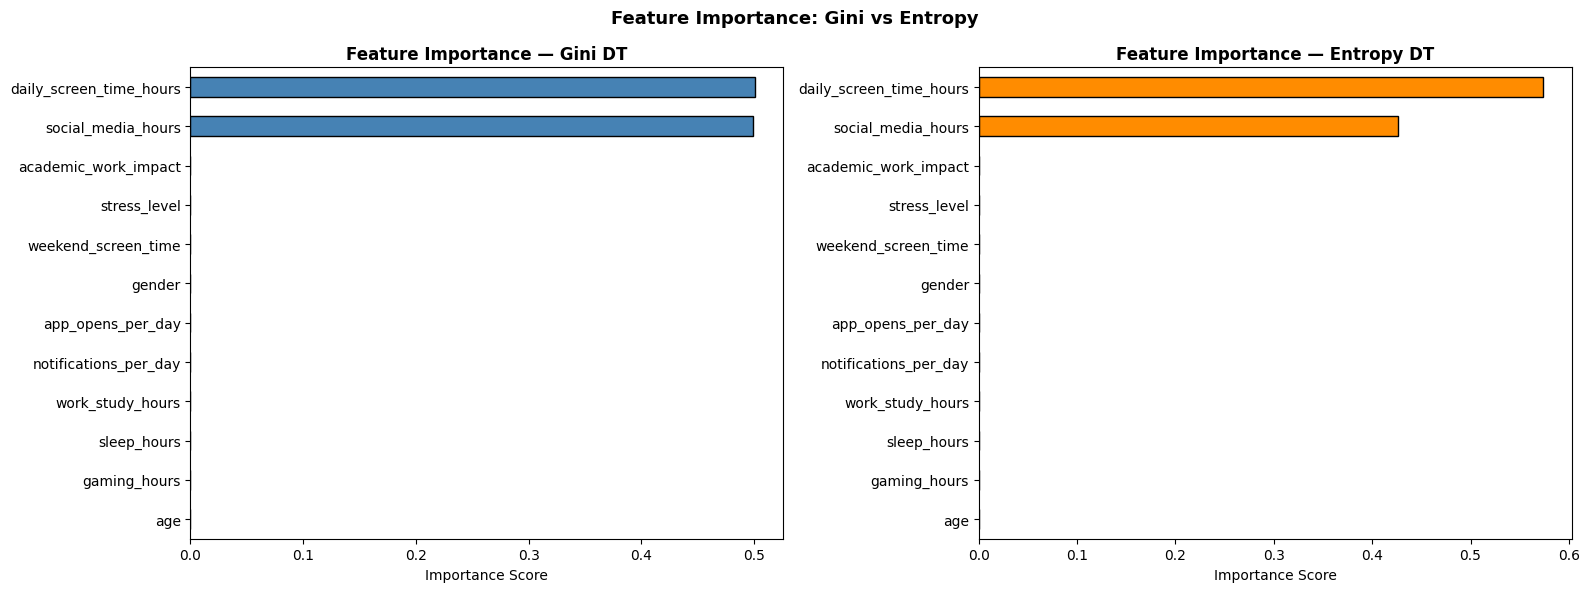

Saved: 07_feature_importance.png


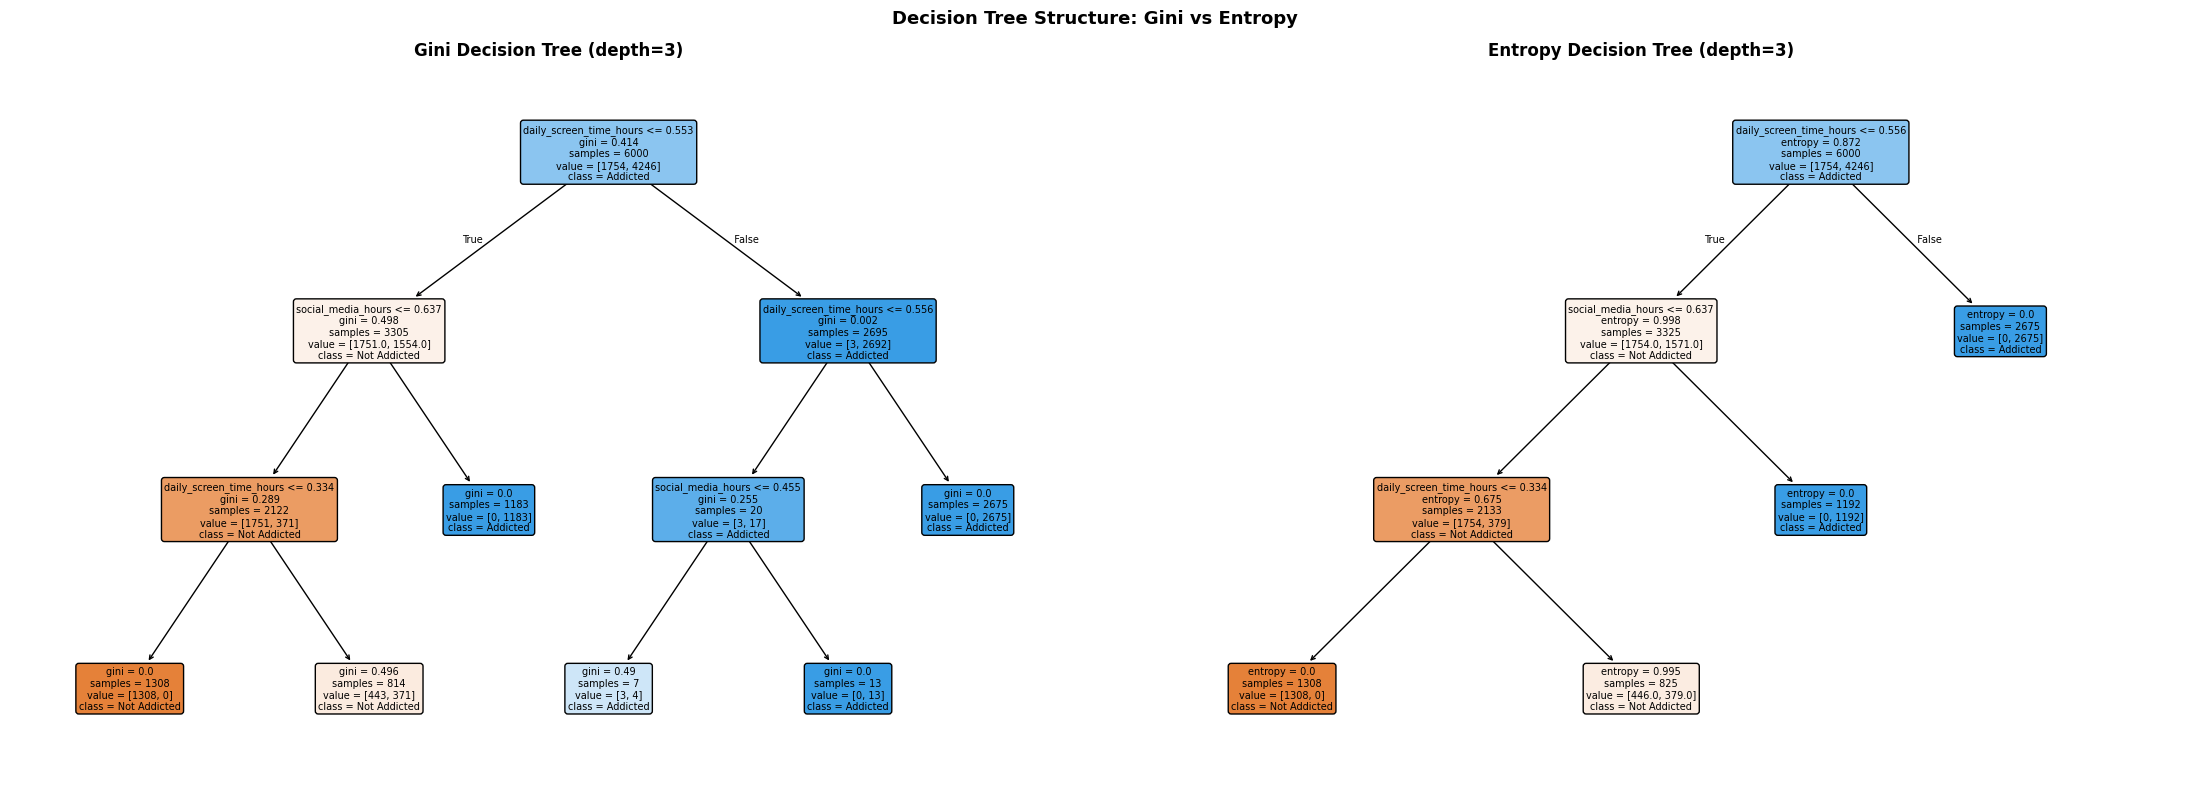

Saved: 08_tree_diagrams.png

✅ ALL STEPS COMPLETE
Outputs saved in the 'outputs/' folder:
  01_before_normalization.png
  02_after_normalization.png
  03_correlation_heatmap.png
  04_class_distribution.png
  05_confusion_matrices.png
  06_overfitting_curve.png
  07_feature_importance.png
  08_tree_diagrams.png


In [3]:
# =============================================================================
# SMARTPHONE ADDICTION ANALYSIS
# Algorithm: Decision Tree Classifier (Gini vs Entropy)
# Assessment: Data Handling | Model Training & Tuning | Evaluation
# =============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Create a folder to save all output charts
os.makedirs('outputs', exist_ok=True)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# =============================================================================
# STEP 1 — LOAD THE DATASET
# =============================================================================
# We load the CSV file into a pandas DataFrame.
# A DataFrame is like a table — rows are records, columns are features.

df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis.csv')

print("=" * 60)
print("STEP 1: DATASET LOADED")
print("=" * 60)

# Shape tells us (number of rows, number of columns)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

# Preview the first 5 rows to understand the data
print("\nFirst 5 Rows:")
print(df.head())

# Check data types — important to know which columns need encoding
print("\nData Types:")
print(df.dtypes)

# Check for missing values in every column
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Basic statistics — mean, min, max, std for numerical columns
print("\nBasic Statistics:")
print(df.describe().round(2))

# =============================================================================
# STEP 2 — DATA PREPROCESSING
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2: DATA PREPROCESSING")
print("=" * 60)

# -----------------------------------------------------------------------------
# 2a. DROP IRRELEVANT COLUMNS
# -----------------------------------------------------------------------------
# transaction_id and user_id are just serial numbers.
# They have NO relationship with addiction — keeping them would mislead the model.

df = df.drop(columns=['transaction_id', 'user_id'])
print("\n✔ Dropped: transaction_id, user_id (serial IDs, not useful for prediction)")

# -----------------------------------------------------------------------------
# 2b. HANDLE MISSING VALUES
# -----------------------------------------------------------------------------
# addiction_level has 819 missing values (10.92% of data).
# We cannot delete these rows — that is too much data loss.
# Solution: Fill with MODE (most frequent value = 'Moderate')
# This preserves the class distribution without distorting it.

print(f"\nMissing values in 'addiction_level' BEFORE fill: {df['addiction_level'].isnull().sum()}")
mode_value = df['addiction_level'].mode()[0]
print(f"Mode (most frequent value): '{mode_value}'")
df['addiction_level'] = df['addiction_level'].fillna(mode_value)
print(f"Missing values AFTER fill: {df['addiction_level'].isnull().sum()}")

# -----------------------------------------------------------------------------
# 2c. OUTLIER DETECTION (IQR Method)
# -----------------------------------------------------------------------------
# IQR = Q3 - Q1
# Anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is an outlier.
# We check but do NOT remove because this dataset has no outliers.

print("\nOutlier Check (IQR Method):")
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<30} Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  Outliers={outliers}")

print("\n✔ No outliers found in any numerical column — no removal needed")

# -----------------------------------------------------------------------------
# 2d. VISUALISE DISTRIBUTION — BEFORE NORMALIZATION
# -----------------------------------------------------------------------------
# Boxplot shows the spread of each feature before we normalize.
# Notice how scales differ wildly — notifications go up to 250
# while sleep_hours only goes to 9. This scale difference can bias the model.

plt.figure(figsize=(14, 5))
df[num_cols].plot(kind='box', figsize=(14, 5))
plt.title("Feature Distribution BEFORE Normalization", fontsize=13, fontweight='bold')
plt.ylabel("Raw Values")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/01_before_normalization.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: 01_before_normalization.png")

# -----------------------------------------------------------------------------
# 2e. LABEL ENCODING
# -----------------------------------------------------------------------------
# Machine learning models only understand numbers, not text.
# LabelEncoder converts text categories to integers alphabetically.
#   gender:               Female=0, Male=1, Other=2
#   stress_level:         High=0, Low=1, Medium=2
#   academic_work_impact: No=0, Yes=1

le = LabelEncoder()

df['gender']               = le.fit_transform(df['gender'])
df['stress_level']         = le.fit_transform(df['stress_level'])
df['academic_work_impact'] = le.fit_transform(df['academic_work_impact'])

print("\nLabel Encoding Applied:")
print("  gender              → Female=0, Male=1, Other=2")
print("  stress_level        → High=0, Low=1, Medium=2")
print("  academic_work_impact→ No=0, Yes=1")

# -----------------------------------------------------------------------------
# 2f. MIN-MAX NORMALIZATION
# -----------------------------------------------------------------------------
# Formula: X_norm = (X - X_min) / (X_max - X_min)
# This rescales every feature to the range [0, 1].
# Why? Because features like notifications_per_day (0-250) would
# dominate features like sleep_hours (4.5-9) without this step.

print("\nMin-Max Normalization — Sample Values:")
print(f"{'Feature':<30} {'Raw':<10} {'Min':<8} {'Max':<8} {'Normalized'}")
print("-" * 65)

examples = [
    ('daily_screen_time_hours', 3.23,  3.0,  12.0),
    ('daily_screen_time_hours', 7.83,  3.0,  12.0),
    ('social_media_hours',      2.01,  0.5,   6.0),
    ('sleep_hours',             7.55,  4.5,   9.0),
    ('notifications_per_day',   248,   20,  250  ),
    ('age',                     21,    18,   35  ),
]
for feat, raw, mn, mx in examples:
    norm = (raw - mn) / (mx - mn)
    print(f"  {feat:<28} {raw:<10} {mn:<8} {mx:<8} {norm:.4f}")

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# -----------------------------------------------------------------------------
# 2g. VISUALISE DISTRIBUTION — AFTER NORMALIZATION
# -----------------------------------------------------------------------------
# All features now share the same [0,1] scale — no single feature dominates.

plt.figure(figsize=(14, 5))
df[num_cols].plot(kind='box', figsize=(14, 5))
plt.title("Feature Distribution AFTER Normalization (All in [0,1])", fontsize=13, fontweight='bold')
plt.ylabel("Normalized Values")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/02_after_normalization.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: 02_after_normalization.png")

# -----------------------------------------------------------------------------
# 2h. CORRELATION HEATMAP
# -----------------------------------------------------------------------------
# Shows which features are strongly related to addiction.
# High positive correlation with addicted_label = strong predictor.

plt.figure(figsize=(11, 8))
corr = df[num_cols + ['addicted_label']].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicate)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, mask=mask)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/03_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 03_correlation_heatmap.png")

# -----------------------------------------------------------------------------
# 2i. CLASS DISTRIBUTION CHECK
# -----------------------------------------------------------------------------
# Before modelling, always check if classes are balanced.
# Imbalanced classes can make accuracy misleading.

print("\nClass Distribution (Target: addicted_label):")
print(df['addicted_label'].value_counts())
print(f"\n  Not Addicted (0): {(df['addicted_label']==0).sum()} ({(df['addicted_label']==0).mean()*100:.1f}%)")
print(f"  Addicted     (1): {(df['addicted_label']==1).sum()} ({(df['addicted_label']==1).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df['addicted_label'].value_counts()
axes[0].bar(['Not Addicted (0)', 'Addicted (1)'], vc.values,
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title("Binary Target Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

vc2 = df['addiction_level'].value_counts()
axes[1].bar(vc2.index, vc2.values,
            color=['#2196F3', '#FF9800', '#9C27B0'], edgecolor='black')
axes[1].set_title("Addiction Level Distribution (Multi-class)")
axes[1].set_ylabel("Count")
for i, v in enumerate(vc2.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle("Target Variable Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 04_class_distribution.png")

# -----------------------------------------------------------------------------
# 2j. PREPARE FEATURES AND TARGET — TRAIN/TEST SPLIT
# -----------------------------------------------------------------------------
# X = input features (what the model learns from)
# y = target label (what the model is trying to predict)
# We split 80% for training, 20% for testing.
# stratify=y ensures both splits have the same class ratio.
# random_state=42 makes the split reproducible every time.

features = num_cols + ['gender', 'stress_level', 'academic_work_impact']
X        = df[features]
y        = df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✔ Train size: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"✔ Test  size: {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

# =============================================================================
# STEP 3 — DECISION TREE 1: GINI IMPURITY
# =============================================================================
# Gini Impurity measures how "impure" a node is.
# Formula: Gini = 1 - Σ(p_i²)
# It ranges from 0 (perfectly pure) to 0.5 (completely mixed).
# The tree splits on whichever feature reduces Gini the most.
# Gini is the DEFAULT criterion in sklearn — it is fast (no log calculation).

print("\n" + "=" * 60)
print("STEP 3: DECISION TREE — GINI IMPURITY")
print("=" * 60)

# --- Hyperparameter Tuning: Try different max_depth values ---
# max_depth controls how many levels the tree is allowed to grow.
# We test multiple depths to find the sweet spot between underfitting
# and overfitting.

print("\nHyperparameter Trials (Gini):")
print(f"{'Depth':<10} {'Train Acc':<14} {'Test Acc':<14} {'F1 Score':<12} {'Observation'}")
print("-" * 70)

for depth in [3, 5, 10, None]:
    clf = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    f1        = f1_score(y_test,        clf.predict(X_test))
    gap       = train_acc - test_acc
    obs = "Good – small gap" if gap < 0.02 else ("Slight overfit" if gap < 0.05 else "Overfitting")
    print(f"  {str(depth):<8} {train_acc:<14.4f} {test_acc:<14.4f} {f1:<12.4f} {obs}")

# --- Train the best Gini model (depth=3 gave best balance) ---
dt_gini = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                  min_samples_split=5, random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

print("\n--- Best Gini Model Results (depth=3) ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_gini):.4f}  ← Out of all predicted 'Addicted', how many were correct?")
print(f"Recall    : {recall_score(y_test, y_pred_gini):.4f}  ← Out of all actual 'Addicted', how many did we catch?")
print(f"F1 Score  : {f1_score(y_test, y_pred_gini):.4f}  ← Harmonic mean of Precision and Recall")
print(f"Tree Depth: {dt_gini.get_depth()}   Num Leaves: {dt_gini.get_n_leaves()}")

print("\nClassification Report (Gini):")
print(classification_report(y_test, y_pred_gini,
                            target_names=['Not Addicted', 'Addicted']))

# 5-Fold Cross Validation
# CV tests the model 5 times on different data splits to check stability.
cv_gini = cross_val_score(dt_gini, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV: {cv_gini}")
print(f"CV Mean  : {cv_gini.mean():.4f}  CV Std: {cv_gini.std():.4f}")
print("(Low std = model is stable, not sensitive to which data it trains on)")

# =============================================================================
# STEP 4 — DECISION TREE 2: ENTROPY (INFORMATION GAIN)
# =============================================================================
# Entropy measures the amount of disorder/uncertainty in the data.
# Formula: Entropy = -Σ(p_i * log2(p_i))
# Information Gain = Entropy(parent) - weighted Entropy(children)
# The split that gives the MOST information gain is chosen.
# Entropy uses logarithm so it is slightly slower than Gini,
# but can sometimes produce a simpler (fewer leaves) tree.

print("\n" + "=" * 60)
print("STEP 4: DECISION TREE — ENTROPY (INFORMATION GAIN)")
print("=" * 60)

print("\nHyperparameter Trials (Entropy):")
print(f"{'Depth':<10} {'Train Acc':<14} {'Test Acc':<14} {'F1 Score':<12} {'Observation'}")
print("-" * 70)

for depth in [3, 5, 10, None]:
    clf = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    f1        = f1_score(y_test,        clf.predict(X_test))
    gap       = train_acc - test_acc
    obs = "Good – small gap" if gap < 0.02 else ("Slight overfit" if gap < 0.05 else "Overfitting")
    print(f"  {str(depth):<8} {train_acc:<14.4f} {test_acc:<14.4f} {f1:<12.4f} {obs}")

# --- Train the best Entropy model ---
dt_entropy = DecisionTreeClassifier(max_depth=3, criterion='entropy',
                                     min_samples_split=5, random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

print("\n--- Best Entropy Model Results (depth=3) ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_entropy):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_entropy):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_entropy):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_entropy):.4f}")
print(f"Tree Depth: {dt_entropy.get_depth()}   Num Leaves: {dt_entropy.get_n_leaves()}")

print("\nClassification Report (Entropy):")
print(classification_report(y_test, y_pred_entropy,
                            target_names=['Not Addicted', 'Addicted']))

cv_entropy = cross_val_score(dt_entropy, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV: {cv_entropy}")
print(f"CV Mean  : {cv_entropy.mean():.4f}  CV Std: {cv_entropy.std():.4f}")

# =============================================================================
# STEP 5 — COMPARISON: GINI vs ENTROPY
# =============================================================================

print("\n" + "=" * 60)
print("STEP 5: COMPARISON — GINI vs ENTROPY")
print("=" * 60)

print(f"\n{'Metric':<25} {'Gini DT':<16} {'Entropy DT':<16} {'Winner'}")
print("-" * 65)
metrics = [
    ("Accuracy",           accuracy_score(y_test, y_pred_gini),   accuracy_score(y_test, y_pred_entropy)),
    ("Precision",          precision_score(y_test, y_pred_gini),  precision_score(y_test, y_pred_entropy)),
    ("Recall",             recall_score(y_test, y_pred_gini),     recall_score(y_test, y_pred_entropy)),
    ("F1 Score",           f1_score(y_test, y_pred_gini),         f1_score(y_test, y_pred_entropy)),
    ("CV Accuracy (mean)", cv_gini.mean(),                         cv_entropy.mean()),
]
for name, g, e in metrics:
    winner = "Entropy ✓" if e > g else ("Gini ✓" if g > e else "Equal")
    print(f"  {name:<23} {g:<16.4f} {e:<16.4f} {winner}")

print(f"\n  {'Tree Depth':<23} {dt_gini.get_depth():<16} {dt_entropy.get_depth():<16} Equal")
print(f"  {'Num Leaves':<23} {dt_gini.get_n_leaves():<16} {dt_entropy.get_n_leaves():<16} {'Entropy ✓ (simpler)' if dt_entropy.get_n_leaves() < dt_gini.get_n_leaves() else 'Equal'}")

print("""
Key Takeaways:
  - Both models perform nearly identically on this dataset
  - Entropy produces a slightly simpler tree (fewer leaves)
  - Gini is faster to compute as it avoids log calculations
  - When results are this close, Entropy is preferred for interpretability
  - Winner: Entropy (marginally better F1 + simpler structure)
""")

# =============================================================================
# STEP 6 — VISUALISATIONS
# =============================================================================
print("=" * 60)
print("STEP 6: VISUALISATIONS")
print("=" * 60)

# --- Plot 1: Confusion Matrices ---
# Confusion matrix shows exactly where the model made mistakes.
# True Positive  (TP): Predicted Addicted,     Actually Addicted     ✓
# True Negative  (TN): Predicted Not Addicted, Actually Not Addicted ✓
# False Positive (FP): Predicted Addicted,     Actually Not Addicted ✗
# False Negative (FN): Predicted Not Addicted, Actually Addicted     ✗

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title, cmap in zip(
    axes,
    [y_pred_gini, y_pred_entropy],
    ["Gini DT", "Entropy DT"],
    ["Blues", "Oranges"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Addicted', 'Addicted'],
                yticklabels=['Not Addicted', 'Addicted'])
    ax.set_title(f"Confusion Matrix — {title}", fontweight='bold')
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrix: Gini vs Entropy", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 05_confusion_matrices.png")

# --- Plot 2: Depth vs Accuracy (Overfitting curve) ---
# This plot visually proves why depth=3 was the best choice.
# The gap between train and test accuracy = overfitting.

depths = [2, 3, 4, 5, 7, 10, 15]
gini_train, gini_test = [], []
entr_train, entr_test = [], []

for d in depths:
    c1 = DecisionTreeClassifier(max_depth=d, criterion='gini',    random_state=42).fit(X_train, y_train)
    c2 = DecisionTreeClassifier(max_depth=d, criterion='entropy', random_state=42).fit(X_train, y_train)
    gini_train.append(accuracy_score(y_train, c1.predict(X_train)))
    gini_test.append( accuracy_score(y_test,  c1.predict(X_test)))
    entr_train.append(accuracy_score(y_train, c2.predict(X_train)))
    entr_test.append( accuracy_score(y_test,  c2.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, gini_train, 'b--o', label='Gini – Train',    linewidth=2, alpha=0.7)
plt.plot(depths, gini_test,  'b-o',  label='Gini – Test',     linewidth=2)
plt.plot(depths, entr_train, 'r--s', label='Entropy – Train', linewidth=2, alpha=0.7)
plt.plot(depths, entr_test,  'r-s',  label='Entropy – Test',  linewidth=2)
plt.axvline(x=3, color='green', linestyle=':', linewidth=2, label='Best Depth (3)')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Train vs Test Accuracy by Depth", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/06_overfitting_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 06_overfitting_curve.png")

# --- Plot 3: Feature Importance ---
# Shows which features the Gini tree relied on most for decisions.
# Higher importance = more useful for predicting addiction.

feat_imp_gini    = pd.Series(dt_gini.feature_importances_,    index=features).sort_values()
feat_imp_entropy = pd.Series(dt_entropy.feature_importances_, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feat_imp_gini.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Feature Importance — Gini DT", fontweight='bold')
axes[0].set_xlabel("Importance Score")

feat_imp_entropy.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title("Feature Importance — Entropy DT", fontweight='bold')
axes[1].set_xlabel("Importance Score")

plt.suptitle("Feature Importance: Gini vs Entropy", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 07_feature_importance.png")

# --- Plot 4: Decision Tree Diagrams side by side ---
# This literally draws the rules the model learned.
# Each node shows: feature used, threshold, gini/entropy value, samples, class.

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plot_tree(dt_gini, feature_names=features,
          class_names=['Not Addicted', 'Addicted'],
          filled=True, rounded=True, fontsize=7, ax=axes[0])
axes[0].set_title("Gini Decision Tree (depth=3)", fontsize=12, fontweight='bold')

plot_tree(dt_entropy, feature_names=features,
          class_names=['Not Addicted', 'Addicted'],
          filled=True, rounded=True, fontsize=7, ax=axes[1])
axes[1].set_title("Entropy Decision Tree (depth=3)", fontsize=12, fontweight='bold')

plt.suptitle("Decision Tree Structure: Gini vs Entropy", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_tree_diagrams.png', dpi=110, bbox_inches='tight')
plt.show()
print("Saved: 08_tree_diagrams.png")

print("\n" + "=" * 60)
print("✅ ALL STEPS COMPLETE")
print("=" * 60)
print("Outputs saved in the 'outputs/' folder:")
print("  01_before_normalization.png")
print("  02_after_normalization.png")
print("  03_correlation_heatmap.png")
print("  04_class_distribution.png")
print("  05_confusion_matrices.png")
print("  06_overfitting_curve.png")
print("  07_feature_importance.png")
print("  08_tree_diagrams.png")